In [1]:
import os
from pathlib import Path

PROJECT_DIR = Path(os.getenv('PROJECT_DIR'))
os.makedirs(PROJECT_DIR / 'paper/figures/subject_leakage/text', exist_ok=True)

In [2]:
import mlflow
client = mlflow.tracking.MlflowClient()

all_runs = mlflow.search_runs(search_all_experiments=True)
all_runs = all_runs[all_runs['tags.experiment_name'] == 'Encoder fine-tuning repeated']

In [3]:
all_runs['subject_leakage'] = all_runs['params.data_leakage'].apply(lambda x: x == 'True')

### Learning curves

In [4]:
def get_metric_history(run_id, metric, metric_name):
    metrics = client.get_metric_history(run_id, metric)

    x = [m.step + 1 for m in metrics]
    y = [m.value for m in metrics]
    return pd.DataFrame({'Epoch': x, metric_name: y})

In [5]:
metric_map = {
    'train_mae_epoch': 'Train MAE',
    'val_mae_epoch': 'Val. MAE',
    'train_r2_epoch': 'Train R²',
    'val_r2_epoch': 'Val. R²',
}

In [6]:
LATEX_LINEWIDTH = 500.484 / 72.27

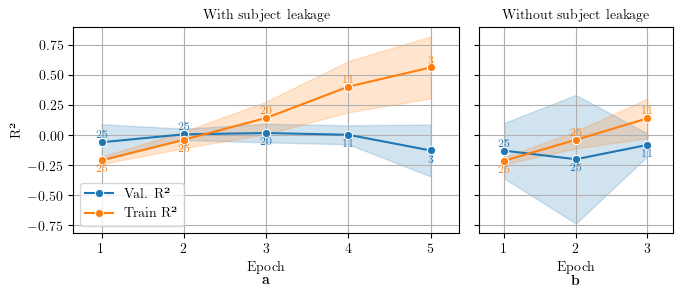

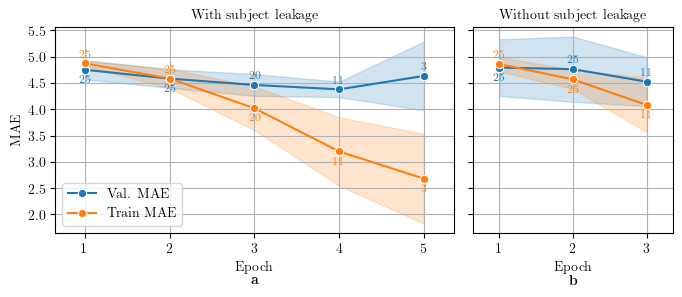

In [7]:
import math

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Liberation Sans'
plt.rcParams['text.usetex'] = True
plt.rc('text.latex', preamble=r'''
\usepackage{amsmath} 
\usepackage{helvet} 
\renewcommand{\familydefault}{\sfdefault}
''')
plt.rcParams.update({'font.size': 10})

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import Bbox
import seaborn as sns
import pandas as pd

epoch_cutoff = math.inf
label = 'Epoch'

flip = True

for i, (pair, metric_name) in enumerate([
    (['val_r2_epoch', 'train_r2_epoch'], 'R²'),
    (['val_mae_epoch', 'train_mae_epoch'], 'MAE'),
]):
    fig = plt.figure(figsize=(LATEX_LINEWIDTH, LATEX_LINEWIDTH * 4 / 9))

    # infer number of epochs
    max_epoch_left = 0
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[~all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])

        epoch_left = max(metrics[metrics['Epoch'] <= epoch_cutoff]['Epoch']) - 1
        if epoch_left > max_epoch_left:
            max_epoch_left = epoch_left
    max_epoch_right = 0
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])
        epoch_right = max(metrics[metrics['Epoch'] <= epoch_cutoff]['Epoch']) - 1
        if epoch_right > max_epoch_right:
            max_epoch_right = epoch_right

    # space proportional to the number of epochs
    lw, rw = [
        max_epoch_left / (max_epoch_left + max_epoch_right),
        max_epoch_right / (max_epoch_left + max_epoch_right),
    ]
    if flip:
        lw, rw = rw, lw
    widths = [lw, rw]
    
    gs = gridspec.GridSpec(1, 2, width_ratios=widths)
    left_axis = fig.add_subplot(gs[0])
    right_axis = fig.add_subplot(gs[1], sharey=left_axis)

    ax1, ax2 = left_axis, right_axis
    if flip:
        ax1, ax2 = right_axis, left_axis

    _min, _max = math.inf, -math.inf

    # on ax1
    ax1_metrics = {}
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[~all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])
        metrics = metrics[metrics['Epoch'] <= epoch_cutoff]

        ax1_metrics[metric] = metrics.groupby('Epoch')[metric_map[metric]].mean()
        ax1_metrics[f'{metric}_count'] = metrics.groupby('Epoch')[metric_map[metric]].count()

        min_value = ax1_metrics[metric].min()
        if min_value < _min:
            _min = min_value
        max_value = ax1_metrics[metric].max()
        if max_value > _max:
            _max = max_value

        sns.lineplot(
            data=metrics,
            x='Epoch',
            y=metric_map[metric],
            marker='o',
            label=metric_map[metric],
            errorbar='sd',
            ax=ax1
        )

    # on ax2
    ax2_metrics = {}
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])
        metrics = metrics[metrics['Epoch'] <= epoch_cutoff]

        ax2_metrics[metric] = metrics.groupby('Epoch')[metric_map[metric]].mean()
        ax2_metrics[f'{metric}_count'] = metrics.groupby('Epoch')[metric_map[metric]].count()

        min_value = ax2_metrics[metric].min()
        if min_value < _min:
            _min = min_value
        max_value = ax2_metrics[metric].max()
        if max_value > _max:
            _max = max_value

        sns.lineplot(
            data=metrics,
            x='Epoch',
            y=metric_map[metric],
            marker='o',
            label=metric_map[metric],
            errorbar='sd',
            ax=ax2
        )

    # plot annotations on ax1
    for epoch in ax1_metrics[pair[0]].index:
        first_val = ax1_metrics[pair[0]].loc[epoch]
        second_val = ax1_metrics[pair[1]].loc[epoch]
        count_first = ax1_metrics[f'{pair[0]}_count'].loc[epoch]
        count_second = ax1_metrics[f'{pair[1]}_count'].loc[epoch]
    
        higher_y = max(first_val, second_val)
        lower_y = min(first_val, second_val)
        is_val_higher = first_val > second_val
    
        ax1.text(epoch, higher_y + (_max - _min) * 0.08, f'{count_first if is_val_higher else count_second}', ha='center', va='center', fontsize=8, color='#1f77b4' if is_val_higher else '#ff7f0e')
        ax1.text(epoch, lower_y - (_max - _min) * 0.04, f'{count_second if is_val_higher else count_first}', ha='center', va='top', fontsize=8, color='#1f77b4' if not is_val_higher else '#ff7f0e')

    # plot annotations on ax2
    for epoch in ax2_metrics[pair[0]].index:
        first_val = ax2_metrics[pair[0]].loc[epoch]
        second_val = ax2_metrics[pair[1]].loc[epoch]
        count_first = ax2_metrics[f'{pair[0]}_count'].loc[epoch]
        count_second = ax2_metrics[f'{pair[1]}_count'].loc[epoch]
    
        higher_y = max(first_val, second_val)
        lower_y = min(first_val, second_val)
        is_val_higher = first_val > second_val
    
        ax2.text(epoch, higher_y + (_max - _min) * 0.08, f'{count_first if is_val_higher else count_second}', ha='center', va='center', fontsize=8, color='#1f77b4' if is_val_higher else '#ff7f0e')
        ax2.text(epoch, lower_y - (_max - _min) * 0.04, f'{count_second if is_val_higher else count_first}', ha='center', va='top', fontsize=8, color='#1f77b4' if not is_val_higher else '#ff7f0e')

    # customize left plot
    left_axis.grid(which='both')
    left_axis.set_ylabel(metric_name)
    left_axis.set_xlabel(f'{label}\n\\textbf{{a}}')

    ax1.set_title('Without subject leakage', fontsize=10)
    left_axis.xaxis.set_major_locator(MultipleLocator(1))
    ticks = left_axis.get_yticks()
    step = ticks[1] - ticks[0]
    if metric_name == 'MAE': 
        left_axis.yaxis.set_major_locator(MultipleLocator(step))
    left_axis.legend(loc='lower left')
    
    # customize right plot
    right_axis.grid(which='both')
    right_axis.get_legend().remove()
    right_axis.set_xlabel(f'{label}\n\\textbf{{b}}')
    right_axis.set_ylabel(None)
    ax2.set_title('With subject leakage', fontsize=10)
    right_axis.xaxis.set_major_locator(MultipleLocator(1))
    plt.setp(right_axis.get_yticklabels(), visible=False)

    # paddings
    padding = 0.35
    left_axis.set_xlim(1 - padding, 5 + padding)
    right_axis.set_xlim(1 - padding, 3 + padding)

    plt.tight_layout()

    # pad MAE 0.2 inches to align axes with R2
    bbox = 'tight'
    if metric_name == 'MAE':
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        pad_left = 0.2  # inches
        bbox = Bbox([[bbox.x0 - pad_left, bbox.y0], [bbox.x1, bbox.y1]])

    plt.savefig(PROJECT_DIR / f'paper/figures/subject_leakage/text/0{i+2}-{pair[0].split("_")[1]}-curve.pdf', bbox_inches=bbox, pad_inches=0)
    plt.savefig(PROJECT_DIR / f'paper/figures/subject_leakage/text/0{i+2}-{pair[0].split("_")[1]}-curve.png', bbox_inches=bbox, pad_inches=0)
    plt.show()